# 60 years of countries getting richer and healthier, in plain SQL

Income, population, life expectancy, child mortality and CO2 emissions for **217 countries from 1960 to 2023**, from the World Bank's open API. Seven questions in SQL only: a growth index with `FIRST_VALUE`, ranking climbers with `RANK`, year-on-year change with `LAG`, a population-weighted average and the classic **income-versus-life-expectancy** relationship measured with a correlation coefficient built from sums (`ln`, `sqrt`). Python only runs the queries and draws the charts.

**Data:** [World Development Indicators](https://data.worldbank.org/) from the World Bank (CC BY 4.0). Run `python build_db.py` once to download the indicators (about 20 MB of JSON) into a SQLite database, then point `WORLDBANK_DB` at that file. The SQL uses `ln`, `sqrt` and `power`, which need SQLite 3.35 or newer.

**Reading the data.** GDP per capita is in current US dollars (not adjusted for prices or purchasing power), so exchange-rate swings show up in it. Regional and income-group aggregates are removed, leaving real countries.

In [1]:
import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path(os.environ.get("WORLDBANK_DB", "worldbank.db"))
AMBER, BLUE, GREY = "#e8a33d", "#2b6cb0", "#a0aec0"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "figure.dpi": 110})
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

con = sqlite3.connect(DB_PATH)


def q(sql):
    """Run a query and return the result as a DataFrame."""
    return pd.read_sql_query(sql, con)

## 0. What is in the database?

In [2]:
tables = q("SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name").name
pd.DataFrame({"table": tables,
              "rows": [con.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0] for t in tables]})

,table,rows
0,countries,217
1,indicators,13873


## 1. How did Poland's economy grow compared with its neighbours?

`FIRST_VALUE(gdp_per_capita) OVER (PARTITION BY country ORDER BY year)` takes each country's 1995 value as the base, so every country is rescaled to 100 in 1995 and the lines show relative growth.

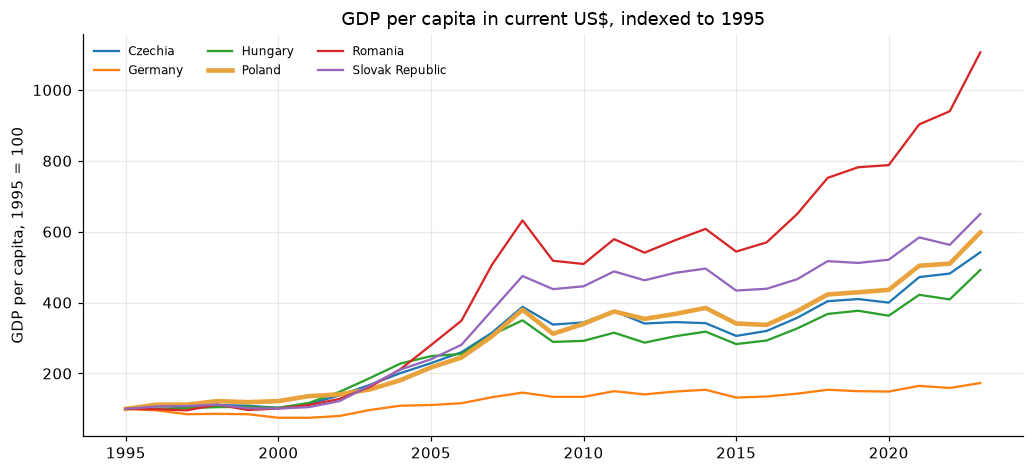

,country,year,gdp_per_capita,index_1995
144,Romania,2023,18244.0,1106.0
173,Slovak Republic,2023,24615.0,650.0
115,Poland,2023,22145.0,598.0
28,Czechia,2023,31762.0,542.0
86,Hungary,2023,22209.0,492.0
57,Germany,2023,54777.0,173.0


In [3]:
index = q("""
SELECT c.name AS country, i.year,
       ROUND(i.gdp_per_capita)                                       AS gdp_per_capita,
       ROUND(100.0 * i.gdp_per_capita
             / FIRST_VALUE(i.gdp_per_capita) OVER (PARTITION BY i.country_code ORDER BY i.year), 0) AS index_1995
FROM indicators i
JOIN countries c ON c.code = i.country_code
WHERE i.country_code IN ('POL', 'DEU', 'CZE', 'HUN', 'SVK', 'ROU')
  AND i.year >= 1995 AND i.gdp_per_capita IS NOT NULL
ORDER BY c.name, i.year
""")

fig, ax = plt.subplots(figsize=(9.5, 4.4))
for country, g in index.groupby("country"):
    ax.plot(g.year, g.index_1995, lw=3 if country == "Poland" else 1.5, label=country,
            color=AMBER if country == "Poland" else None)
ax.set_ylabel("GDP per capita, 1995 = 100")
ax.set_title("GDP per capita in current US$, indexed to 1995")
ax.legend(frameon=False, ncol=3, fontsize=8)
fig.tight_layout()
plt.show()
index[index.year == 2023].sort_values("index_1995", ascending=False)

## 2. Which countries grew richest the fastest?

Two CTEs pick each country's value in the first and the last year, and a join puts them side by side. Only countries with at least a million people are ranked, to keep tiny economies from dominating, and `power()` turns the multiple into an average annual growth rate.

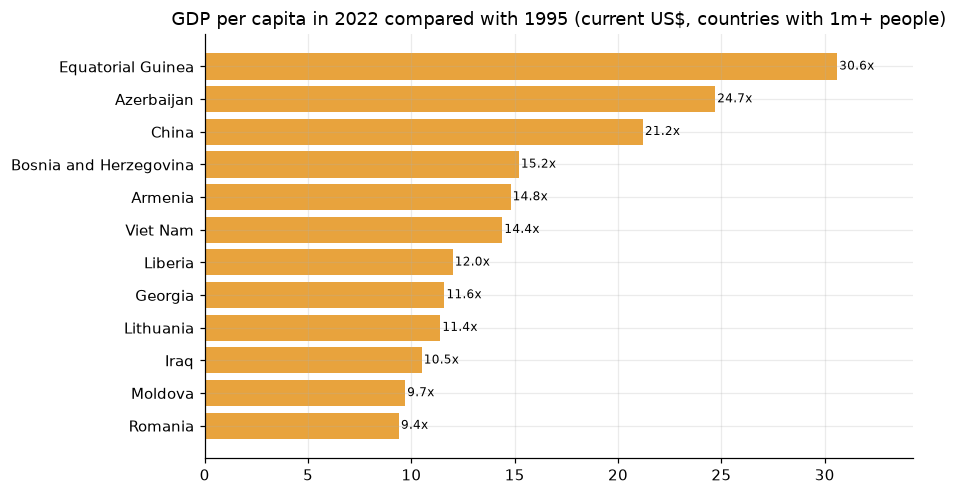

,rank,country,region,gdp_1995,gdp_2022,times_richer,avg_yearly_growth_pct
0,1,Equatorial Guinea,Sub-Saharan Africa,248.0,7589.0,30.6,13.5
1,2,Azerbaijan,Europe & Central Asia,315.0,7771.0,24.7,12.6
2,3,China,East Asia & Pacific,613.0,12971.0,21.2,12.0
3,4,Bosnia and Herzegovina,Europe & Central Asia,502.0,7656.0,15.2,10.6
4,5,Armenia,Europe & Central Asia,444.0,6572.0,14.8,10.5
5,6,Viet Nam,East Asia & Pacific,288.0,4148.0,14.4,10.4
6,7,Liberia,Sub-Saharan Africa,62.0,745.0,12.0,9.6
7,8,Georgia,Europe & Central Asia,578.0,6730.0,11.6,9.5
8,9,Lithuania,Europe & Central Asia,2183.0,24947.0,11.4,9.4
9,10,Iraq,"Middle East, North Africa, Afghanistan & Pakistan",619.0,6521.0,10.5,9.1


In [4]:
growth = q("""
WITH start AS (SELECT country_code, gdp_per_capita AS gdp FROM indicators WHERE year = 1995),
finish AS (SELECT country_code, gdp_per_capita AS gdp, population FROM indicators WHERE year = 2022)
SELECT RANK() OVER (ORDER BY f.gdp / s.gdp DESC)      AS rank,
       c.name                                         AS country,
       c.region,
       ROUND(s.gdp)                                   AS gdp_1995,
       ROUND(f.gdp)                                   AS gdp_2022,
       ROUND(f.gdp / s.gdp, 1)                        AS times_richer,
       ROUND(100 * (power(f.gdp / s.gdp, 1.0 / 27) - 1), 1) AS avg_yearly_growth_pct
FROM start s
JOIN finish    f USING (country_code)
JOIN countries c ON c.code = s.country_code
WHERE f.population >= 1000000 AND s.gdp > 0
ORDER BY times_richer DESC
LIMIT 12
""")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(growth.country[::-1], growth.times_richer[::-1], color=AMBER)
for y, v in enumerate(growth.times_richer[::-1]):
    ax.text(v + 0.1, y, f"{v:.1f}x", va="center", fontsize=8)
ax.set_xlim(0, growth.times_richer.max() * 1.12)
ax.set_title("GDP per capita in 2022 compared with 1995 (current US$, countries with 1m+ people)")
fig.tight_layout()
plt.show()
growth

## 3. Which countries lost the most years of life expectancy?

`LAG(life_expectancy)` per country gives the previous year's value, so the change between 2019 and 2021 is a subtraction.

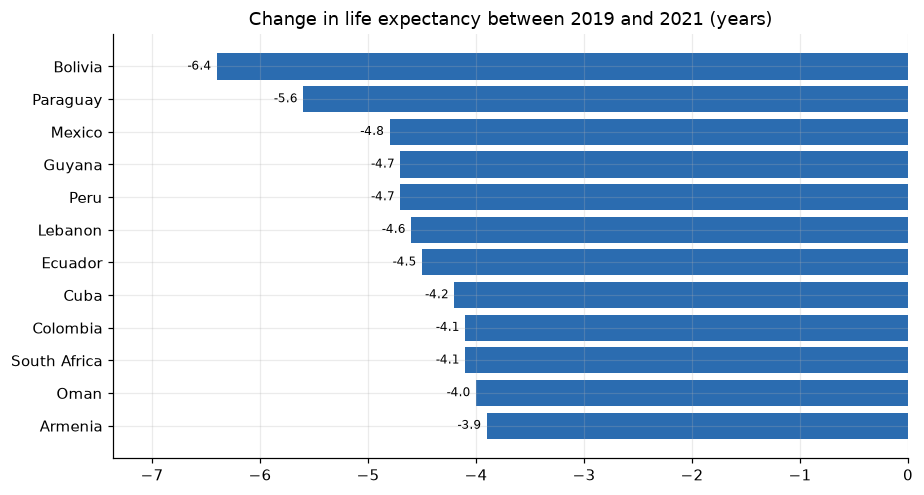

,country,region,le_2019,le_2021,change_years
0,Bolivia,Latin America & Caribbean,67.8,61.4,-6.4
1,Paraguay,Latin America & Caribbean,73.7,68.1,-5.6
2,Mexico,Latin America & Caribbean,74.5,69.8,-4.8
3,Guyana,Latin America & Caribbean,69.1,64.3,-4.7
4,Peru,Latin America & Caribbean,76.3,71.6,-4.7
5,Lebanon,"Middle East, North Africa, Afghanistan & Pakistan",78.2,73.7,-4.6
6,Ecuador,Latin America & Caribbean,77.3,72.7,-4.5
7,Cuba,Latin America & Caribbean,77.4,73.2,-4.2
8,Colombia,Latin America & Caribbean,76.8,72.7,-4.1
9,South Africa,Sub-Saharan Africa,66.1,62.0,-4.1


In [5]:
covid = q("""
WITH yearly AS (
    SELECT country_code, year, life_expectancy,
           LAG(life_expectancy, 2) OVER (PARTITION BY country_code ORDER BY year) AS two_years_before
    FROM indicators
    WHERE year BETWEEN 2018 AND 2021 AND life_expectancy IS NOT NULL
)
SELECT c.name AS country, c.region,
       ROUND(two_years_before, 1)                    AS le_2019,
       ROUND(life_expectancy, 1)                     AS le_2021,
       ROUND(life_expectancy - two_years_before, 1)  AS change_years
FROM yearly y
JOIN countries c ON c.code = y.country_code
WHERE y.year = 2021 AND two_years_before IS NOT NULL
ORDER BY change_years
LIMIT 12
""")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(covid.country[::-1], covid.change_years[::-1], color=BLUE)
for y, v in enumerate(covid.change_years[::-1]):
    ax.text(v - 0.05, y, f"{v:+.1f}", va="center", ha="right", fontsize=8)
ax.set_xlim(covid.change_years.min() * 1.15, 0)
ax.set_title("Change in life expectancy between 2019 and 2021 (years)")
fig.tight_layout()
plt.show()
covid

## 4. How strongly are money and health linked?

Plotting life expectancy against the *logarithm* of income gives the famous Preston curve. Here the correlation coefficient is calculated per year straight from sums (`n*Σxy - Σx*Σy` over the square roots of the variances), using `ln()` for the log of income.

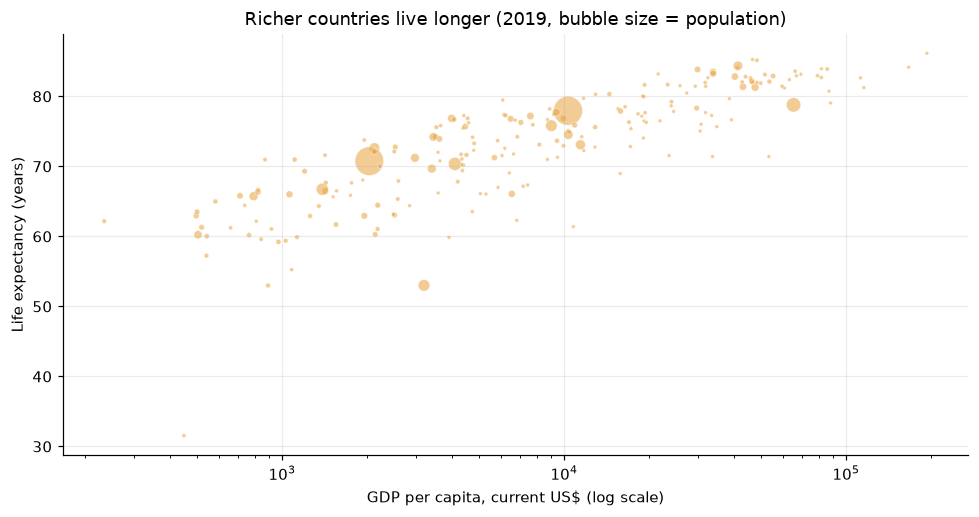

,year,countries,correlation
0,1970,146,0.781
1,1980,163,0.767
2,1990,192,0.791
3,2000,204,0.815
4,2010,213,0.818
5,2020,210,0.852


In [6]:
preston = q("""
WITH data AS (
    SELECT year, ln(gdp_per_capita) AS x, life_expectancy AS y
    FROM indicators
    WHERE year IN (1970, 1980, 1990, 2000, 2010, 2020)
      AND gdp_per_capita > 0 AND life_expectancy IS NOT NULL
),
sums AS (
    SELECT year, COUNT(*) AS n, SUM(x) AS sx, SUM(y) AS sy, SUM(x * y) AS sxy,
           SUM(x * x) AS sxx, SUM(y * y) AS syy
    FROM data
    GROUP BY year
)
SELECT year,
       n AS countries,
       ROUND((n * sxy - sx * sy) / (sqrt(n * sxx - sx * sx) * sqrt(n * syy - sy * sy)), 3) AS correlation
FROM sums
ORDER BY year
""")

scatter = q("""
SELECT c.name AS country, c.region, i.gdp_per_capita, i.life_expectancy, i.population
FROM indicators i JOIN countries c ON c.code = i.country_code
WHERE i.year = 2019 AND i.gdp_per_capita > 0 AND i.life_expectancy IS NOT NULL
""")
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.scatter(scatter.gdp_per_capita, scatter.life_expectancy, s=scatter.population / 4e6 + 6, alpha=0.55, color=AMBER,
           edgecolor="white", lw=0.5)
ax.set_xscale("log")
ax.set_xlabel("GDP per capita, current US$ (log scale)")
ax.set_ylabel("Life expectancy (years)")
ax.set_title("Richer countries live longer (2019, bubble size = population)")
fig.tight_layout()
plt.show()
preston

## 5. How much longer do people live now than in 1960, by region?

A **population-weighted average** (`SUM(le * pop) / SUM(pop)`) gives each region's life expectancy as the average person experiences it, rather than the average country.

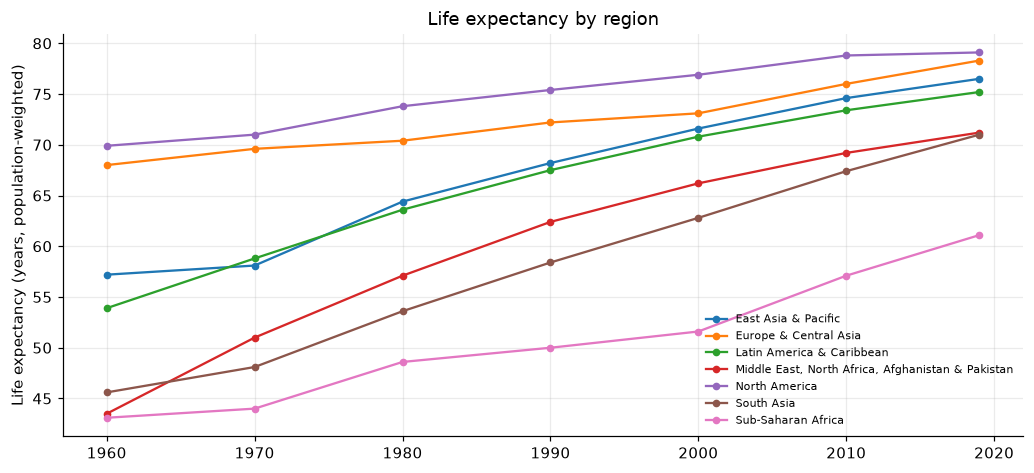

life_expectancy       under5_mortality      
year                                                         1960  2019             1960  2019
region                                                                                        
East Asia & Pacific                                          57.2  76.5            121.0  12.0
Europe & Central Asia                                        68.0  78.3             57.0   7.0
Latin America & Caribbean                                    53.9  75.2            160.0  16.0
Middle East, North Africa, Afghanistan & Pakistan            43.5  71.2            271.0  37.0
North America                                                69.9  79.1             30.0   6.0
South Asia                                                   45.6  71.0            243.0  34.0
Sub-Saharan Africa                                           43.1  61.1            249.0  75.0

In [7]:
regions = q("""
SELECT c.region, i.year,
       ROUND(SUM(i.life_expectancy * i.population) / SUM(i.population), 1) AS life_expectancy,
       ROUND(SUM(i.under5_mortality * i.population) / SUM(i.population), 0) AS under5_mortality
FROM indicators i
JOIN countries c ON c.code = i.country_code
WHERE i.year IN (1960, 1970, 1980, 1990, 2000, 2010, 2019)
  AND i.life_expectancy IS NOT NULL AND i.population IS NOT NULL AND i.under5_mortality IS NOT NULL
GROUP BY c.region, i.year
ORDER BY c.region, i.year
""")

fig, ax = plt.subplots(figsize=(9.5, 4.4))
for region, g in regions.groupby("region"):
    ax.plot(g.year, g.life_expectancy, marker="o", ms=4, label=region.strip())
ax.set_ylabel("Life expectancy (years, population-weighted)")
ax.set_title("Life expectancy by region")
ax.legend(frameon=False, fontsize=7, loc="lower right")
fig.tight_layout()
plt.show()
regions[regions.year.isin([1960, 2019])].pivot(index="region", columns="year", values=["life_expectancy", "under5_mortality"])

## 6. Which countries climbed the income ranking?

`RANK() OVER (ORDER BY gdp_per_capita DESC)` ranks all countries in 2000 and again in 2022, in two CTEs. The difference between the two ranks shows who moved up the league table and who fell. Only countries with data in both years and at least a million people are included.

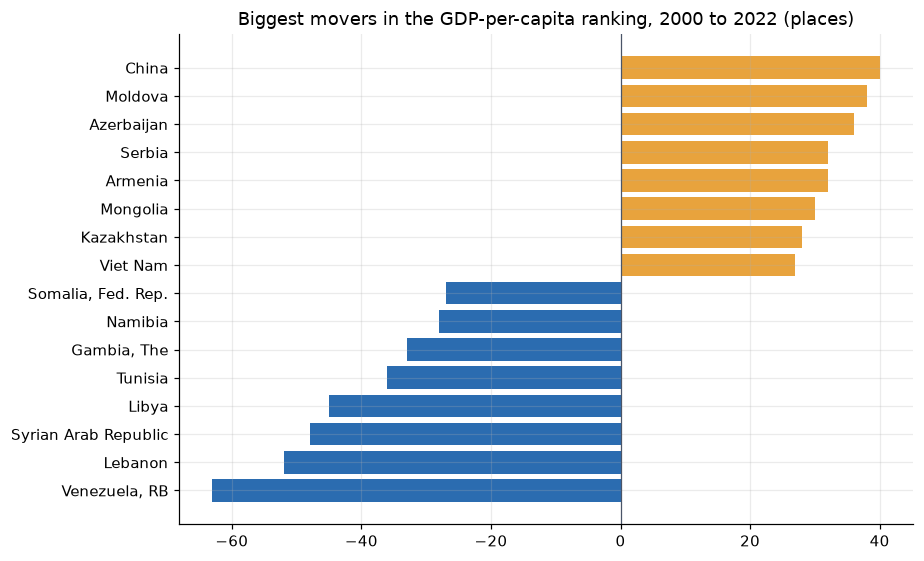

,country,rank_2000,rank_2022,places_gained,gdp_2000,gdp_2022
0,China,92,52,40,969.0,12971.0
1,Moldova,118,80,38,441.0,5744.0
2,Azerbaijan,100,64,36,655.0,7771.0
3,Serbia,91,59,32,975.0,10025.0
4,Armenia,106,74,32,593.0,6572.0
5,Mongolia,115,85,30,476.0,4994.0
6,Kazakhstan,83,55,28,1180.0,11255.0
7,Viet Nam,121,94,27,404.0,4148.0
8,Bulgaria,75,49,26,1621.0,14000.0
9,Georgia,97,71,26,750.0,6730.0


In [8]:
climbers = q("""
WITH r2000 AS (
    SELECT country_code, gdp_per_capita AS gdp,
           RANK() OVER (ORDER BY gdp_per_capita DESC) AS rnk
    FROM indicators
    WHERE year = 2000 AND gdp_per_capita IS NOT NULL AND population >= 1000000
),
r2022 AS (
    SELECT country_code, gdp_per_capita AS gdp,
           RANK() OVER (ORDER BY gdp_per_capita DESC) AS rnk
    FROM indicators
    WHERE year = 2022 AND gdp_per_capita IS NOT NULL AND population >= 1000000
)
SELECT c.name AS country,
       a.rnk  AS rank_2000,
       b.rnk  AS rank_2022,
       a.rnk - b.rnk AS places_gained,
       ROUND(a.gdp) AS gdp_2000,
       ROUND(b.gdp) AS gdp_2022
FROM r2000 a
JOIN r2022 b USING (country_code)
JOIN countries c ON c.code = a.country_code
ORDER BY places_gained DESC
""")

top_up = climbers.head(8)
top_down = climbers.tail(8)
both = pd.concat([top_up, top_down])
fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.barh(both.country[::-1], both.places_gained[::-1], color=[BLUE if v < 0 else AMBER for v in both.places_gained[::-1]])
ax.axvline(0, color="#4a5568", lw=0.8)
ax.set_title("Biggest movers in the GDP-per-capita ranking, 2000 to 2022 (places)")
fig.tight_layout()
plt.show()
climbers.head(10)

## 7. Can a country grow richer and cut emissions at the same time?

Pivoting two years into columns with `MAX(CASE WHEN year = ... THEN ... END)` puts each country's before and after on one row. Countries whose income per person rose by more than a fifth while CO2 per person fell are the ones that appear to have decoupled the two (2005 to 2019, so the pandemic year is excluded).

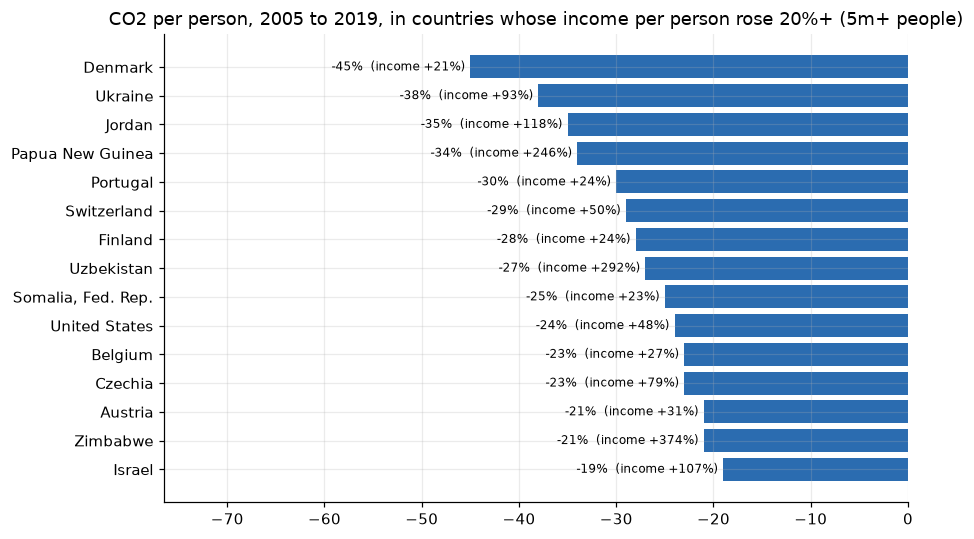

,country,gdp_change_pct,co2_change_pct,co2_2005,co2_2019
0,Denmark,21.0,-45.0,9.3,5.2
1,Ukraine,93.0,-38.0,7.5,4.6
2,Jordan,118.0,-35.0,3.4,2.2
3,Papua New Guinea,246.0,-34.0,0.8,0.5
4,Portugal,24.0,-30.0,6.5,4.5
5,Switzerland,50.0,-29.0,6.3,4.5
6,Finland,24.0,-28.0,11.1,8.0
7,Uzbekistan,292.0,-27.0,4.8,3.5
8,"Somalia, Fed. Rep.",23.0,-25.0,0.1,0.1
9,United States,48.0,-24.0,19.9,15.0


In [9]:
decoupling = q("""
WITH wide AS (
    SELECT country_code,
           MAX(CASE WHEN year = 2005 THEN gdp_per_capita END) AS gdp_2005,
           MAX(CASE WHEN year = 2019 THEN gdp_per_capita END) AS gdp_2019,
           MAX(CASE WHEN year = 2005 THEN co2_per_capita END) AS co2_2005,
           MAX(CASE WHEN year = 2019 THEN co2_per_capita END) AS co2_2019,
           MAX(CASE WHEN year = 2019 THEN population END)     AS pop_2019
    FROM indicators
    WHERE year IN (2005, 2019)
    GROUP BY country_code
)
SELECT c.name AS country,
       ROUND(100.0 * (gdp_2019 / gdp_2005 - 1)) AS gdp_change_pct,
       ROUND(100.0 * (co2_2019 / co2_2005 - 1)) AS co2_change_pct,
       ROUND(co2_2005, 1) AS co2_2005,
       ROUND(co2_2019, 1) AS co2_2019
FROM wide w
JOIN countries c ON c.code = w.country_code
WHERE gdp_2005 > 0 AND co2_2005 > 0 AND pop_2019 >= 5000000
  AND gdp_2019 / gdp_2005 > 1.2 AND co2_2019 < co2_2005
ORDER BY co2_change_pct
LIMIT 15
""")

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(decoupling.country[::-1], decoupling.co2_change_pct[::-1], color=BLUE)
for y, (c, g) in enumerate(zip(decoupling.co2_change_pct[::-1], decoupling.gdp_change_pct[::-1])):
    ax.text(c - 0.5, y, f"{c:.0f}%  (income {g:+.0f}%)", va="center", ha="right", fontsize=8)
ax.set_xlim(decoupling.co2_change_pct.min() * 1.7, 0)
ax.set_title("CO2 per person, 2005 to 2019, in countries whose income per person rose 20%+ (5m+ people)")
fig.tight_layout()
plt.show()
decoupling

## What the queries say

- **Poland grew about six-fold in current dollars since 1995** (index 598), faster than Germany (173), Hungary (492) and Czechia (542) and slightly slower than Slovakia (650). Romania, starting from a lower base, is at 1,106. Because the figures are in current US dollars, part of these gaps is exchange-rate movement and inflation, not only real growth.
- **The biggest multiples come from low starting points and special cases.** Among countries with at least a million people, Equatorial Guinea (30.6 times richer than in 1995), Azerbaijan (24.7) and China (21.2) lead, followed by Bosnia and Herzegovina, Armenia and Viet Nam. Oil and a very low 1995 base explain several of the top spots.
- **The pandemic cost Latin America the most life expectancy.** Between 2019 and 2021, Bolivia lost 6.4 years, Paraguay 5.6 and Mexico 4.8, and eight of the twelve biggest drops are Latin American countries.
- **Money and health stay tightly linked.** The correlation between the logarithm of income per person and life expectancy is 0.78 in 1970 and 0.85 in 2020, across 146 to 213 countries. The relationship has not weakened as countries got richer, it has become slightly stronger.
- **Every region lives much longer than in 1960, but gaps remain.** Population-weighted life expectancy rose from 43 to 61 years in Sub-Saharan Africa, 46 to 71 in South Asia, 44 to 71 in the Middle East and North Africa and 54 to 75 in Latin America. Under-5 mortality in Sub-Saharan Africa fell from 249 to 75 per 1,000 births, but that is still about twelve times North America's 6.
- **The income league table changed a lot.** From 2000 to 2022, China rose 40 places, Moldova 38 and Azerbaijan 36, while Venezuela fell 63 places, Lebanon 52, Syria 48 and Libya 45, all of them countries that went through economic collapse or conflict.
- **Some countries grew richer while cutting emissions per person.** Denmark's CO2 per person fell 45% between 2005 and 2019 while its income rose 21%, and the United States cut 24% while income rose 48%. Read this table carefully: Ukraine's 38% fall (income up 93%) probably reflects the shrinking of heavy industry, and very low-emission countries such as Somalia and Papua New Guinea have noisy figures.

**Limits:** GDP is in current dollars (no inflation or purchasing-power adjustment); emission figures exclude land use and have gaps for some countries; averages by region hide big differences inside each region.

**Techniques covered:** `FIRST_VALUE`, `LAG` with an offset, `RANK` in two CTEs, a correlation coefficient from `SUM`s with `ln` and `sqrt`, population-weighted averages and a year pivot with `MAX(CASE ...)`.
